## Point Cloud Object Segmentation Using PointNet and PointNet++
#### ECE 1508 Project

In [2]:
import os
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from torch.utils.data import Dataset, DataLoader

### 1. Download the Dataset

Download and extract the dataset from the following link into the project folder before running the notebook. 

https://drive.usercontent.google.com/download?id=1W3SEE-dY1sxvlECcOwWSDYemwHEUbJIS&authuser=0 

### 2. Understand the Dataset Structure

In [3]:
DATA_ROOT = "../data/shapenetcore_partanno_segmentation_benchmark_v0_normal"
assert os.path.exists(DATA_ROOT), "Dataset folder not found"

# Look at the subfolders in the dataset
print(os.listdir(DATA_ROOT))

['train_test_split', 'synsetoffset2category.txt', '02958343', '03261776', '02954340', '04099429', '03948459', '02691156', '03001627', '04379243', '02773838', '03636649', '03467517', '03790512', '03624134', '03797390', 'processed', '03642806', '04225987']


In [4]:
cat_file = os.path.join(DATA_ROOT, "synsetoffset2category.txt")

# Create a dict with each category and its id from the synsetoffset2category.txt file
category_mapping = {}
with open(cat_file, "r") as f:
    for line in f:
        name, folder = line.strip().split()
        category_mapping[name] = folder

print("Number of categories:", len(category_mapping))
print("Categories:")
for name, folder in sorted(category_mapping.items()):
    print(f"{name:12s} -> {folder}")

Number of categories: 16
Categories:
Airplane     -> 02691156
Bag          -> 02773838
Cap          -> 02954340
Car          -> 02958343
Chair        -> 03001627
Earphone     -> 03261776
Guitar       -> 03467517
Knife        -> 03624134
Lamp         -> 03636649
Laptop       -> 03642806
Motorbike    -> 03790512
Mug          -> 03797390
Pistol       -> 03948459
Rocket       -> 04099429
Skateboard   -> 04225987
Table        -> 04379243


In [5]:
# Check the number of spamles in each of the presplit train, test, and validation sample sets.
split_dir = os.path.join(DATA_ROOT, "train_test_split")

with open(os.path.join(split_dir, "shuffled_train_file_list.json"), "r") as f:
    train_list = json.load(f)

with open(os.path.join(split_dir, "shuffled_val_file_list.json"), "r") as f:
    val_list = json.load(f)

with open(os.path.join(split_dir, "shuffled_test_file_list.json"), "r") as f:
    test_list = json.load(f)

print("Train samples:", len(train_list))
print("Validation samples:", len(val_list))
print("Test samples:", len(test_list))
print("Total:", len(train_list) + len(val_list) + len(test_list))

print("\nFirst 3 train entries:")
for x in train_list[:3]:
    print(x)

Train samples: 12137
Validation samples: 1870
Test samples: 2874
Total: 16881

First 3 train entries:
shape_data/03624134/3d2cb9d291ec39dc58a42593b26221da
shape_data/02691156/ed73e946a138f3cfbc0909d98a1ff2b4
shape_data/03642806/b272eb1541844f55ad7b15cd0061e5ee


In [6]:
# Check that the first 3 training samples exist in the dataset
for i in range(3):
    sample_rel = train_list[i]
    category_id = sample_rel.split('/')[-2]
    file_id = sample_rel.split('/')[-1]
    sample_path = os.path.join(DATA_ROOT, category_id, file_id + ".txt")
    print("Resolved sample path:", sample_path)
    print("Exists:", os.path.exists(sample_path))

Resolved sample path: ../data/shapenetcore_partanno_segmentation_benchmark_v0_normal/03624134/3d2cb9d291ec39dc58a42593b26221da.txt
Exists: True
Resolved sample path: ../data/shapenetcore_partanno_segmentation_benchmark_v0_normal/02691156/ed73e946a138f3cfbc0909d98a1ff2b4.txt
Exists: True
Resolved sample path: ../data/shapenetcore_partanno_segmentation_benchmark_v0_normal/03642806/b272eb1541844f55ad7b15cd0061e5ee.txt
Exists: True


In [7]:
# Display the size of a sample data set and its first 5 lines 
arr = np.loadtxt(sample_path)

print("Shape:", arr.shape)
print("First 5 rows:\n", arr[:5])

Shape: (2766, 7)
First 5 rows:
 [[-1.8576e-01 -2.3537e-01 -3.9670e-02  3.6540e-02  9.9890e-01 -2.9250e-02
   2.8000e+01]
 [ 1.1680e-02 -2.3537e-01  8.6430e-02  1.3400e-04  9.9980e-01  2.1840e-02
   2.8000e+01]
 [ 6.9720e-02 -2.3537e-01  2.8088e-01  0.0000e+00  1.0000e+00  0.0000e+00
   2.8000e+01]
 [ 1.5076e-01 -2.3862e-01  1.3290e-01  0.0000e+00  1.0000e+00  0.0000e+00
   2.8000e+01]
 [ 1.4201e-01 -2.3862e-01  1.0555e-01 -8.7000e-05  1.0000e+00  4.4000e-05
   2.8000e+01]]


For this dataset, each row contains:
- first 3 columns = coordinates
- next 3 columns = normals
- last column = part label

The ShapeNet Part dataset contains 16 object-category folders, a synsetoffset2category.txt file that maps folder IDs to object names, and an official train_test_split folder with JSON files for the training, validation, and test sets. We verified that one sample loads correctly as a .txt file where each row is one point, with 3D coordinates, surface normals, and a part label for segmentation.

### 3. Data Exploration

In [8]:
def get_category_id(split_entry):
    return split_entry.split('/')[-2]

In [12]:
# Create a reverse mapping array to find the type of object using its category id
reverse_mapping = {v: k for k, v in category_mapping.items()}

# Find how many smaples are in each category 
# And how many of those are train, test, and validation.
train_counts = Counter()
val_counts = Counter()
test_counts = Counter()

for x in train_list:
    train_counts[get_category_id(x)] += 1

for x in val_list:
    val_counts[get_category_id(x)] += 1

for x in test_list:
    test_counts[get_category_id(x)] += 1

print(f"{'Category':12s} {'Train':>6s} {'Val':>6s} {'Test':>6s} {'Train %':>10s} {'Val %':>10s} {'Test %':>10s}")
for folder_id in sorted(reverse_mapping.keys()):
    name = reverse_mapping[folder_id]
    tr = train_counts[folder_id]
    va = val_counts[folder_id]
    te = test_counts[folder_id]
    total = tr + va + te

    train_pct = 100 * tr / total
    val_pct = 100 * va / total
    test_pct = 100 * te / total

    print(f"{name:12s} {tr:6d} {va:6d} {te:6d} {train_pct:10.2f} {val_pct:10.2f} {test_pct:10.2f}")

Category      Train    Val   Test    Train %      Val %     Test %
Airplane       1958    391    341      72.79      14.54      12.68
Bag              54      8     14      71.05      10.53      18.42
Cap              39      5     11      70.91       9.09      20.00
Car             659     81    158      73.39       9.02      17.59
Chair          2658    396    704      70.73      10.54      18.73
Earphone         49      6     14      71.01       8.70      20.29
Guitar          550     78    159      69.89       9.91      20.20
Knife           277     35     80      70.66       8.93      20.41
Lamp           1118    143    286      72.27       9.24      18.49
Laptop          324     44     83      71.84       9.76      18.40
Motorbike       125     26     51      61.88      12.87      25.25
Mug             130     16     38      70.65       8.70      20.65
Pistol          209     30     44      73.85      10.60      15.55
Rocket           46      8     12      69.70      12.12      1

The class proportions across the train, validation, and test splits are generally similar, with most categories falling close to roughly 70–73% training, 9–12% validation, and 16–20% testing. This suggests that the official split is reasonably balanced across classes, although a few categories, such as Motorbike, show a more uneven distribution than the others.

In [12]:
def get_sample_details(split_list,idx):
    entry = split_list[idx]
    parts = entry.split('/')
    category_id = parts[-2]
    file_id = parts[-1]
    sample_path = os.path.join(DATA_ROOT, category_id, file_id + ".txt")

    return [entry, parts, category_id, file_id, sample_path]

In [13]:
# Chcek if each sample object has the same number of points
point_counts = []

# Use just first 500 for speed
for i in range(500):
    entry, parts, category_id, file_id, sample_path = get_sample_details(train_list, i)
    arr = np.loadtxt(sample_path)
    point_counts.append(arr.shape[0])

print("Checked objects:", len(point_counts))
print("Min points for first 500:", np.min(point_counts))
print("Max points for first 500:", np.max(point_counts))
print("Mean points for first 500:", np.mean(point_counts))
print("Unique point counts (first few):", sorted(set(point_counts))[:10])

Checked objects: 500
Min points for first 500: 550
Max points for first 500: 2922
Mean points for first 500: 2611.832
Unique point counts (first few): [550, 634, 935, 1019, 1143, 1269, 1375, 1612, 1617, 1621]


In [14]:
# Find what the part lables for each category is
# And check they are all unique
category_parts = defaultdict(set)

# Use just first 400 samples for speed
for i in range(400):
    entry, parts, category_id, file_id, sample_path = get_sample_details(train_list, i)
    
    arr = np.loadtxt(sample_path)
    seg = arr[:, 6].astype(int)
    category_parts[category_id].update(np.unique(seg))

for folder_id in sorted(category_parts.keys()):
    parts_clean = [int(x) for x in sorted(category_parts[folder_id])]
    print(f"{reverse_mapping[folder_id]:12s} ->    {parts_clean}")

Airplane     ->    [0, 1, 2, 3]
Bag          ->    [4, 5]
Cap          ->    [6, 7]
Car          ->    [8, 9, 10, 11]
Chair        ->    [12, 13, 14, 15]
Earphone     ->    [16, 17, 18]
Guitar       ->    [19, 20, 21]
Knife        ->    [22, 23]
Lamp         ->    [24, 25, 26, 27]
Laptop       ->    [28, 29]
Motorbike    ->    [30, 31, 32, 33, 34, 35]
Mug          ->    [36, 37]
Pistol       ->    [38, 39, 40]
Rocket       ->    [41, 42, 43]
Skateboard   ->    [44, 45, 46]
Table        ->    [47, 48, 49]


In [15]:
def load_raw_sample(sample_path):
    arr = np.loadtxt(sample_path)
    xyz = arr[:, 0:3]
    normals = arr[:, 3:6]
    seg_labels = arr[:, 6].astype(int)
    return arr, xyz, normals, seg_labels

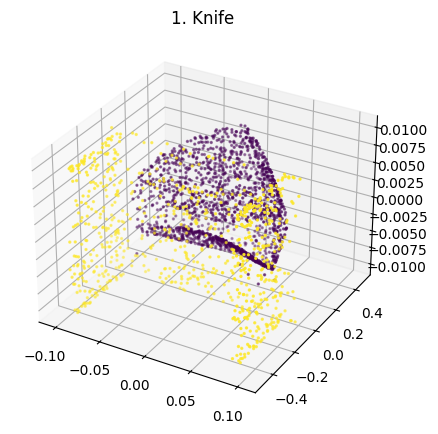

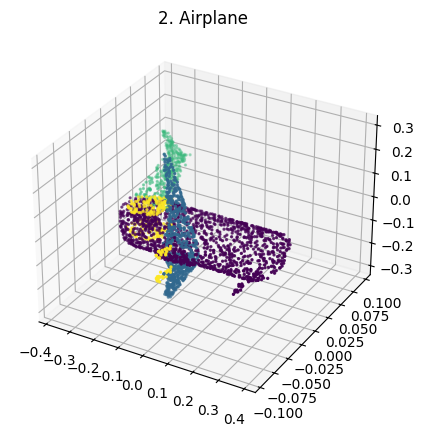

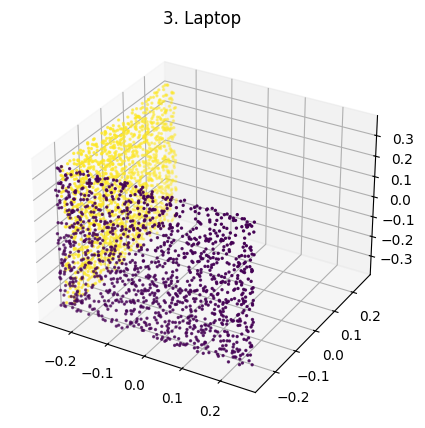

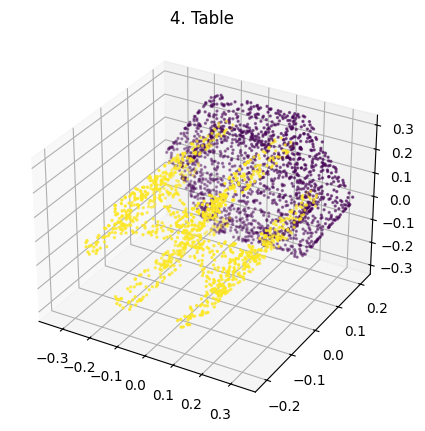

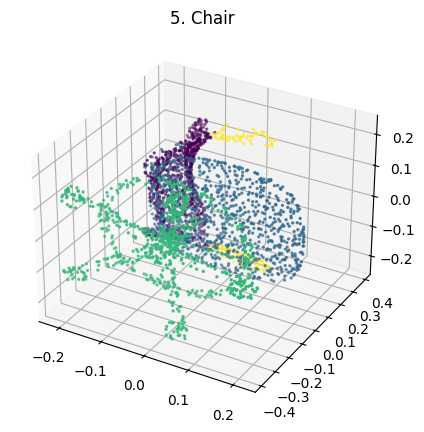

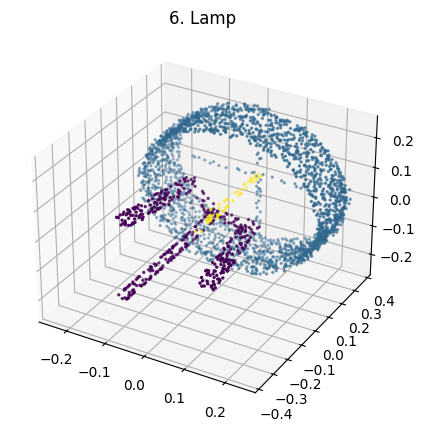

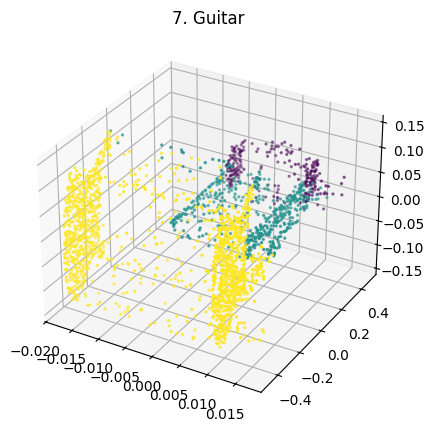

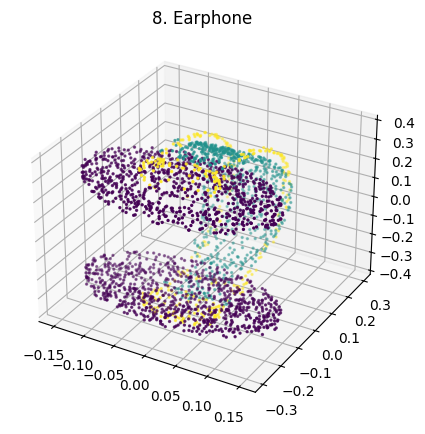

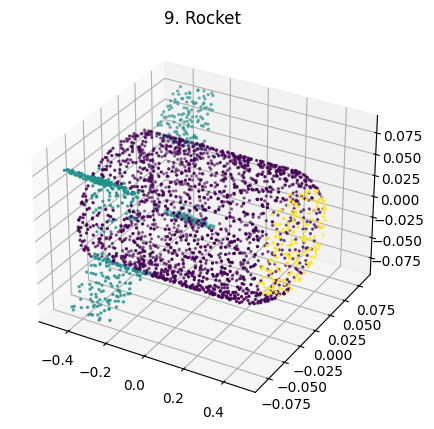

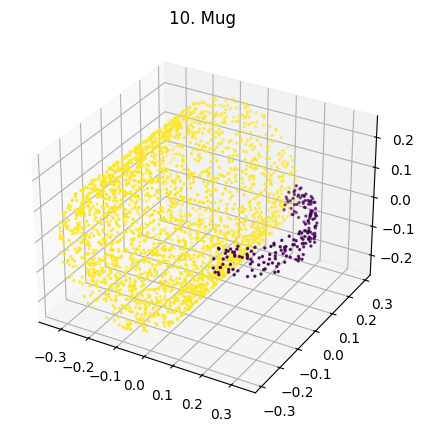

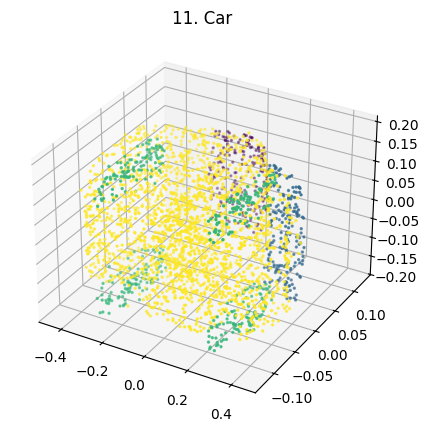

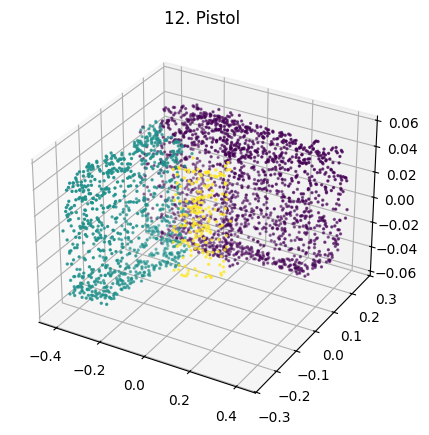

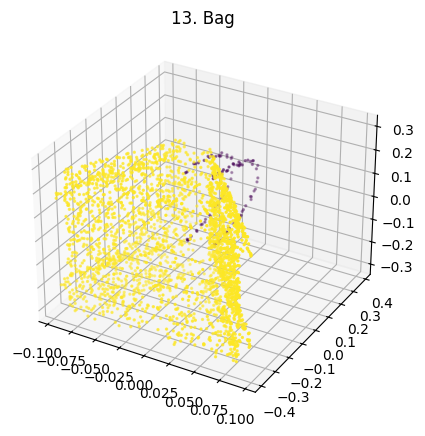

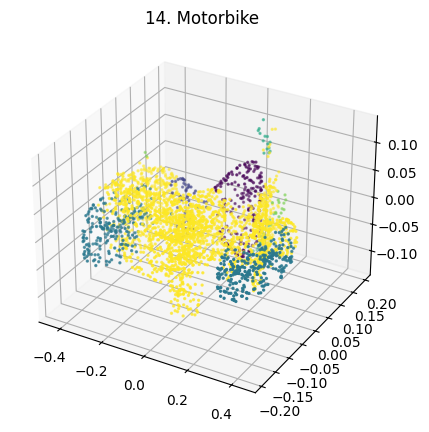

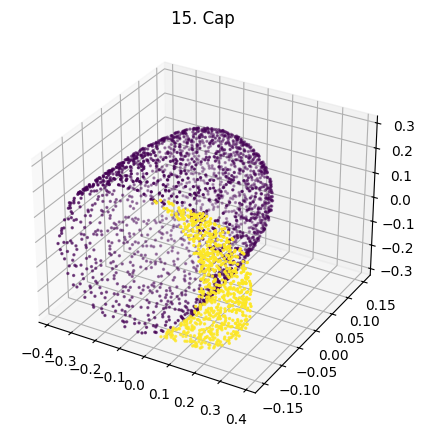

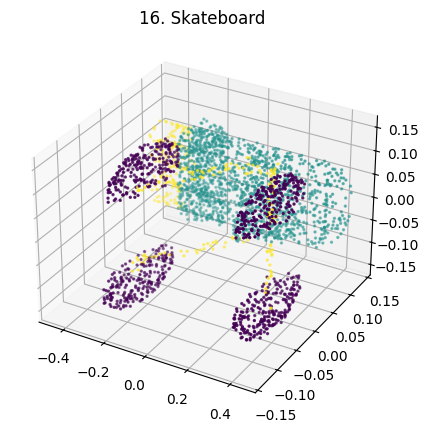

In [16]:
# Visualize first object of each category in a 3D plot
# Each labeled part has a different color
shown = set()
count = 1

for i in range(400):
    entry, parts, category_id, file_id, sample_path = get_sample_details(train_list, i)
    
    if category_id in shown:
        continue
    
    arr, xyz, normals, seg_labels = load_raw_sample(sample_path)
    
    fig = plt.figure(figsize=(5, 5))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(xyz[:, 0], xyz[:, 1], xyz[:, 2], c=seg_labels, s=2)
    ax.set_title(f"{count}. {reverse_mapping[category_id]}")
    plt.show()
    
    shown.add(category_id)
    count += 1
    if count == 17:
        break

From the exploration, we found that the dataset is highly imbalanced across categories, with classes like Table and Chair having far more samples than classes like Cap, Bag, and Rocket. We also found that objects do not all have the same number of points, so preprocessing will need to include point sampling to create a fixed input size for the models. Finally, we confirmed that each object category has its own specific set of valid part labels, which is important for understanding the segmentation task and checking predictions later.

#### Step 3: Preprocessing

In [17]:
# Normalize the point cloud by:
# 1) subtract the centroid so the shape is centered at the origin
# 2) divide by the farthest point distance so all the points are in a unit sphere
def normalize_point_cloud(points):
    centroid = np.mean(points, axis=0)
    points = points - centroid
    max_dist = np.max(np.sqrt(np.sum(points ** 2, axis=1)))
    points = points / max_dist
    return points

In [18]:
# Test normalizing on one data object
entry, parts, category_id, file_id, sample_path = get_sample_details(train_list, 0)

arr, xyz, normals, seg_labels = load_raw_sample(sample_path)

xyz_norm = normalize_point_cloud(xyz)

print("Centroid after normalization:", np.mean(xyz_norm, axis=0))
print("Max radius after normalization:", np.max(np.sqrt(np.sum(xyz_norm ** 2, axis=1))))

Centroid after normalization: [-7.92488238e-18  3.88479460e-17  3.46636574e-20]
Max radius after normalization: 1.0


In [19]:
# Sample a fixed number of points, since each object have different num of points
# Start with 1024 points but we will test training on different options
# if object has more than 1024 points, randomly choose 1024
# if it has fewer than 1024, sample with replacement 
def sample_points(points, labels, num_points=1024):
    n = len(points)
    if n >= num_points:
        idx = np.random.choice(n, num_points, replace=False)
    else:
        idx = np.random.choice(n, num_points, replace=True)
    return points[idx], labels[idx]

In [20]:
# Test the sampling on one data object
xyz_sampled, seg_sampled = sample_points(
    xyz_norm, seg_labels, num_points=1024
)

print("Original points shape:", xyz.shape)
print("Sampled points shape:", xyz_sampled.shape)
print("Sampled labels shape:", seg_sampled.shape)
print("Unique labels after sampling:", [int(x) for x in sorted(set(seg_sampled))])

Original points shape: (2252, 3)
Sampled points shape: (1024, 3)
Sampled labels shape: (1024,)
Unique labels after sampling: [22, 23]


In [21]:
# Sample a fixed number of points with their normals
def sample_points_with_normals(points, norms, labels, num_points=1024):
    n = len(points)
    if n >= num_points:
        idx = np.random.choice(n, num_points, replace=False)
    else:
        idx = np.random.choice(n, num_points, replace=True)
    return points[idx], norms[idx], labels[idx]

In [22]:
# Test the sampling with normals on one data object
norms = arr[:, 3:6]

xyz_sampled, norms_sampled, seg_sampled = sample_points_with_normals(
    xyz_norm, norms, seg_labels, num_points=1024
)

print("Original points shape:", xyz.shape)
print("Sampled points shape:", xyz_sampled.shape)
print("Sampled normal points shape:", norms_sampled.shape)
print("Sampled labels shape:", seg_sampled.shape)
print("Unique labels after sampling:", [int(x) for x in sorted(set(seg_sampled))])

Original points shape: (2252, 3)
Sampled points shape: (1024, 3)
Sampled normal points shape: (1024, 3)
Sampled labels shape: (1024,)
Unique labels after sampling: [22, 23]


In [23]:
# Convert the points with normals to tensors
features_tensor = np.concatenate([xyz_sampled, norms_sampled], axis=1)
features_tensor = torch.tensor(features_tensor, dtype=torch.float32)
labels_tensor = torch.tensor(seg_sampled, dtype=torch.long)

print(features_tensor.shape, features_tensor.dtype)
print(labels_tensor.shape, labels_tensor.dtype)

torch.Size([1024, 6]) torch.float32
torch.Size([1024]) torch.int64


In [24]:
# Combine the previous normalization, sampling with normals, and tensor conversion processing into one function
# As well as adding an object category classification label
category_to_idx = {name: i for i, name in enumerate(sorted(category_mapping.keys()))}
folder_to_class_idx = {folder: category_to_idx[name] for name, folder in category_mapping.items()}

def preprocess_sample_with_class(sample_path, category_id, num_points=1024):
    arr, xyz, norms, seg_labels = load_raw_sample(sample_path)
    
    xyz = normalize_point_cloud(xyz)
    xyz, norms, seg_labels = sample_points_with_normals(xyz, norms, seg_labels, num_points=num_points)
    class_label = folder_to_class_idx[category_id]

    features_tensor = np.concatenate([xyz, norms], axis=1)
    features_tensor = torch.tensor(features_tensor, dtype=torch.float32)
    seg_labels = torch.tensor(seg_labels, dtype=torch.long)
    class_label = torch.tensor(class_label, dtype=torch.long)

    return features_tensor, class_label, seg_labels

In [25]:
# Test processing function on one data object
points, class_label, seg_labels = preprocess_sample_with_class(sample_path, category_id)

print("Points:", points.shape)
print("Class label:", class_label.item())
print("Seg labels:", seg_labels.shape)
print("Unique labels:", torch.unique(seg_labels))

Points: torch.Size([1024, 6])
Class label: 7
Seg labels: torch.Size([1024])
Unique labels: tensor([22, 23])


In [ ]:
# Create a class that creates datasets that are compatible to train using pytorch 
# The dataset returns processed data item from the ShapeNet Part Data when called dataset[i]
# Have conditional option to add the normals to data points
class ShapeNetPartDataset(Dataset):
    def __init__(self, data_root, split_list, category_mapping, num_points=1024, normals=False):
        self.data_root = data_root
        self.split_list = split_list
        self.category_mapping = category_mapping
        self.num_points = num_points
        self.normals = normals
        
        self.category_to_idx = {name: i for i, name in enumerate(sorted(category_mapping.keys()))}
        self.folder_to_class_idx = {folder: self.category_to_idx[name] for name, folder in category_mapping.items()}

    def __len__(self):
        return len(self.split_list)

    def __getitem__(self, idx):
        entry, parts, category_id, file_id, sample_path = get_sample_details(self.split_list, idx)
        
        sample_path = os.path.join(self.data_root, category_id, file_id + ".txt")
        arr, xyz, norms, seg_labels = load_raw_sample(sample_path)
        
        xyz = normalize_point_cloud(xyz)
        class_label = self.folder_to_class_idx[category_id]

        if self.normals:
            xyz, norms, seg_labels = sample_points_with_normals(xyz, norms, seg_labels, num_points=self.num_points)
            features_tensor = np.concatenate([xyz, norms], axis=1)
        else:
            xyz, seg_labels = sample_points(xyz, seg_labels, num_points=self.num_points)
            features_tensor = xyz

        features_tensor = torch.tensor(features_tensor, dtype=torch.float32)
        class_label = torch.tensor(class_label, dtype=torch.long)
        seg_labels = torch.tensor(seg_labels, dtype=torch.long)

        return features_tensor, class_label, seg_labels

In [27]:
# Create the 3 datasets and check that their lengths match the original split
train_dataset = ShapeNetPartDataset(DATA_ROOT, train_list, category_mapping, num_points=1024, normals=False)
val_dataset = ShapeNetPartDataset(DATA_ROOT, val_list, category_mapping, num_points=1024, normals=False)
test_dataset = ShapeNetPartDataset(DATA_ROOT, test_list, category_mapping, num_points=1024, normals=False)

print("Train dataset size:", len(train_dataset))
print("Val dataset size:", len(val_dataset))
print("Test dataset size:", len(test_dataset))

Train dataset size: 12137
Val dataset size: 1870
Test dataset size: 2874


In [28]:
# Create dataloader for every dataset: training, testing, and validation
# Start with batch size 20 but we will test training with different options
train_loader = DataLoader(train_dataset, batch_size=20, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=20, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=20, shuffle=False)

In [29]:
# Test the dataloader by checking the batch details
batch_points, batch_class_labels, batch_seg_labels = next(iter(train_loader))

print("Batch points shape:", batch_points.shape)

print("\nBatch class labels shape:", batch_class_labels.shape)
print("Unique classes:", torch.unique(batch_class_labels))

print("\nBatch seg labels shape:", batch_seg_labels.shape)
print("Unique labels:", torch.unique(batch_seg_labels))

Batch points shape: torch.Size([20, 1024, 3])

Batch class labels shape: torch.Size([20])
Unique classes: tensor([ 0,  3,  4,  6,  7,  8, 15])

Batch seg labels shape: torch.Size([20, 1024])
Unique labels: tensor([ 0,  1,  2,  3,  8,  9, 10, 11, 12, 13, 14, 19, 20, 21, 22, 23, 24, 25,
        27, 47, 48, 49])


In preprocessing, we converted raw ShapeNet Part objects into a consistent format for training by normalizing each point cloud, sampling a fixed number of points per object, and keeping the segmentation labels aligned with the sampled points. We then wrapped the official train, validation, and test splits into PyTorch dataset and dataloader objects so the data is ready to feed into PointNet and PointNet++. Two variables we will adjust while training are the sampling size (1024 commonly used with PointNet and PointNet++) and the batch size (20).

Surface normals add extra local shape information by telling the model the direction the surface is facing at each point, which can help improve part segmentation, especially for finer details. However, they also make the input larger and the setup a bit more complex, so we’ll start with just the 3D coordinates (x,y,z) as a clean baseline, then try adding normals later to see if they improve performance.

### 4. Baseline Data Checks

In [30]:
# Define the expected labels from the information found above
expected_parts = {
    "Airplane": [0, 1, 2, 3],
    "Bag": [4, 5],
    "Cap": [6, 7],
    "Car": [8, 9, 10, 11],
    "Chair": [12, 13, 14, 15],
    "Earphone": [16, 17, 18],
    "Guitar": [19, 20, 21],
    "Knife": [22, 23],
    "Lamp": [24, 25, 26, 27],
    "Laptop": [28, 29],
    "Motorbike": [30, 31, 32, 33, 34, 35],
    "Mug": [36, 37],
    "Pistol": [38, 39, 40],
    "Rocket": [41, 42, 43],
    "Skateboard": [44, 45, 46],
    "Table": [47, 48, 49]
}

In [31]:
# Check several random samples for validtity post processing
indices = [0, 200, 400, 600, 800, 1000]
class_idx_to_name = {i: name for i, name in enumerate(sorted(category_mapping.keys()))}

for idx in indices:
    points, class_label, seg_labels = train_dataset[idx]
    cat_name = class_idx_to_name[class_label.item()]

    print("--------------------------------------------------")
    print("Category:", cat_name)

    print("\nPoints shape:", tuple(points.shape))
    print("Class label:", class_label.item())
    print("Segmentation labels shape:", tuple(seg_labels.shape))

    print("\nPoint and label length match:", points.shape[0] == seg_labels.shape[0])

    print("\nExpected labels:", expected_parts[cat_name])
    print("Actual labels:", sorted(torch.unique(seg_labels).tolist()))
    print("Valid actual labels:", all(x in expected_parts[cat_name] for x in torch.unique(seg_labels).tolist()))

    print("\nCentroid:", points.mean(dim=0))
    print("Max radius:", torch.sqrt(torch.sum(points ** 2, dim=1)).max().item())

    print("\nNaN in points:", torch.isnan(points).any().item())
    print("Inf in points:", torch.isinf(points).any().item())
    print("NaN in seg labels:", torch.isnan(seg_labels.float()).any().item())

--------------------------------------------------
Category: Knife

Points shape: (1024, 3)
Class label: 7
Segmentation labels shape: (1024,)

Point and label length match: True

Expected labels: [22, 23]
Actual labels: [22, 23]
Valid actual labels: True

Centroid: tensor([0.0007, 0.0185, 0.0002])
Max radius: 0.9993324279785156

NaN in points: False
Inf in points: False
NaN in seg labels: False
--------------------------------------------------
Category: Motorbike

Points shape: (1024, 3)
Class label: 10
Segmentation labels shape: (1024,)

Point and label length match: True

Expected labels: [30, 31, 32, 33, 34, 35]
Actual labels: [30, 31, 32, 33, 35]
Valid actual labels: True

Centroid: tensor([-0.0149,  0.0023, -0.0034])
Max radius: 0.999627411365509

NaN in points: False
Inf in points: False
NaN in seg labels: False
--------------------------------------------------
Category: Airplane

Points shape: (1024, 3)
Class label: 0
Segmentation labels shape: (1024,)

Point and label length 

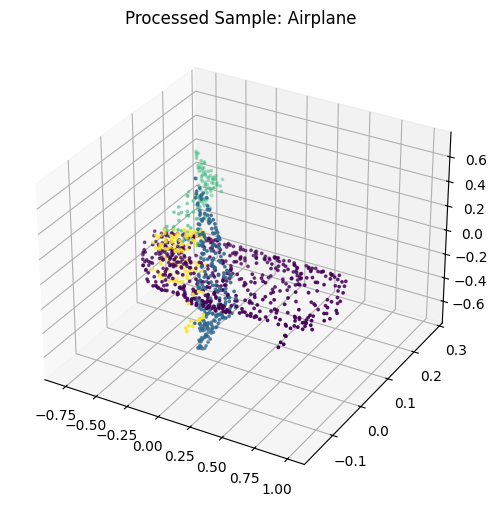

In [32]:
# Visualize random processed samples to ensure that is still valid
points, class_label, seg_labels = train_dataset[1]
points_np = points.numpy()
seg_np = seg_labels.numpy()

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(points_np[:, 0], points_np[:, 1], points_np[:, 2], c=seg_np, s=3)
ax.set_title(f"Processed Sample: {class_idx_to_name[class_label.item()]}")
plt.show()

In [33]:
# Check one batch from the dataloader and its the class distribution
batch_points, batch_class_labels, batch_seg_labels = next(iter(train_loader))

print("\nBatch points shape:", batch_points.shape)
print("Batch seg labels shape:", batch_seg_labels.shape)

print("\nBatch class labels shape:", batch_class_labels.shape)
print("Class labels in batch:", batch_class_labels.tolist())
print("Unique classes in batch:", sorted(set(batch_class_labels.tolist())))


Batch points shape: torch.Size([20, 1024, 3])
Batch seg labels shape: torch.Size([20, 1024])

Batch class labels shape: torch.Size([20])
Class labels in batch: [15, 4, 3, 0, 9, 15, 0, 4, 4, 8, 4, 11, 4, 4, 4, 15, 15, 15, 15, 4]
Unique classes in batch: [0, 3, 4, 8, 9, 11, 15]


In [34]:
# Check that all three splits load correctly
for name, ds in [("Train", train_dataset), ("Validation", val_dataset), ("Test", test_dataset)]:
    points, class_label, seg_labels = ds[0]
    print(name)
    print(" Points shape:", points.shape)
    print(" Class label:", class_label.item())
    print(" Seg labels shape:", seg_labels.shape)
    print()

Train
 Points shape: torch.Size([1024, 3])
 Class label: 7
 Seg labels shape: torch.Size([1024])

Validation
 Points shape: torch.Size([1024, 3])
 Class label: 0
 Seg labels shape: torch.Size([1024])

Test
 Points shape: torch.Size([1024, 3])
 Class label: 4
 Seg labels shape: torch.Size([1024])



Here we verified that the preprocessed samples and batches have the correct shapes, valid labels, and clean numerical values. We also confirmed that normalization and point sampling preserved the object structure and that all train, validation, and test splits load correctly, meaning the dataset pipeline is ready for model training.